# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


#### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

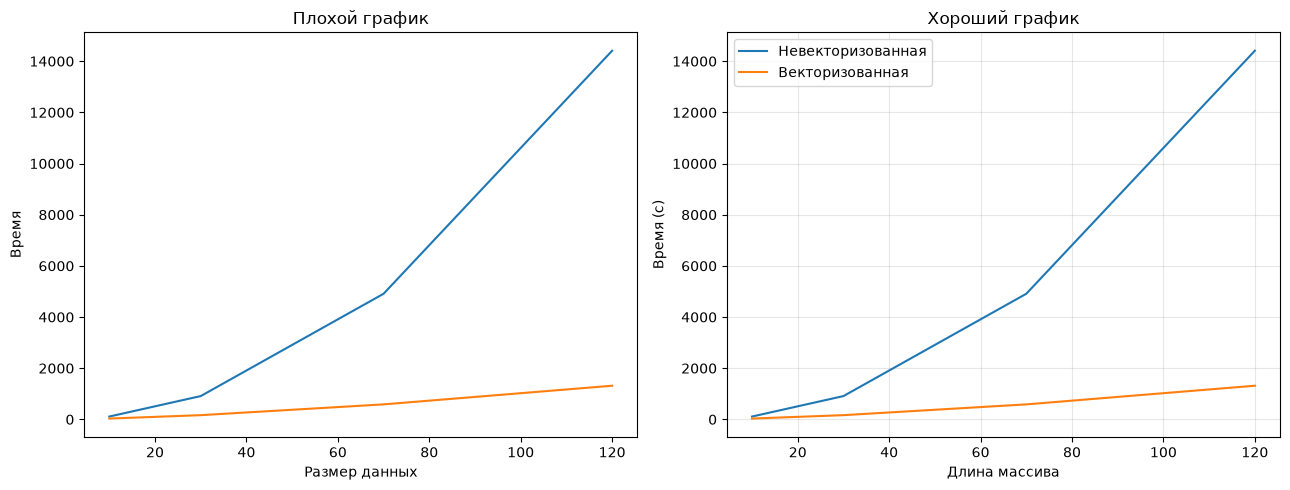

In [1]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import time
import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

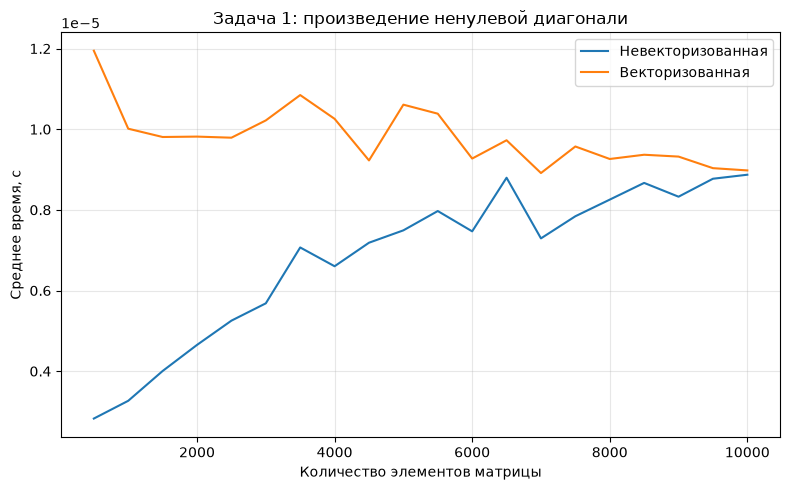

In [2]:
reload_solution_modules()

data_sizes = np.arange(500, 10_001, 500)
time_non_vectorized, time_vectorized = [], []


for size in data_sizes:
    rows = int(np.sqrt(size))
    columns = int(np.ceil(size / rows))
    data = np.random.default_rng().integers(0, 10, size=(rows, columns))
    python_data = data.tolist()
    
    start = time.perf_counter()
    for _ in range(20):
        functions.prod_non_zero_diag(python_data)
    time_non_vectorized.append((time.perf_counter() - start) / 20)
    
    start = time.perf_counter()
    for _ in range(20):
        functions_vectorized.prod_non_zero_diag(data)
    time_vectorized.append((time.perf_counter() - start) / 20)

figure, axis = plt.subplots(figsize=(8, 5))

axis.plot(data_sizes, time_non_vectorized, label="Невекторизованная")
axis.plot(data_sizes, time_vectorized, label="Векторизованная")

axis.set_title("Задача 1: произведение ненулевой диагонали")
axis.set_xlabel("Количество элементов матрицы")
axis.set_ylabel("Среднее время, с")

axis.grid(True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()


 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


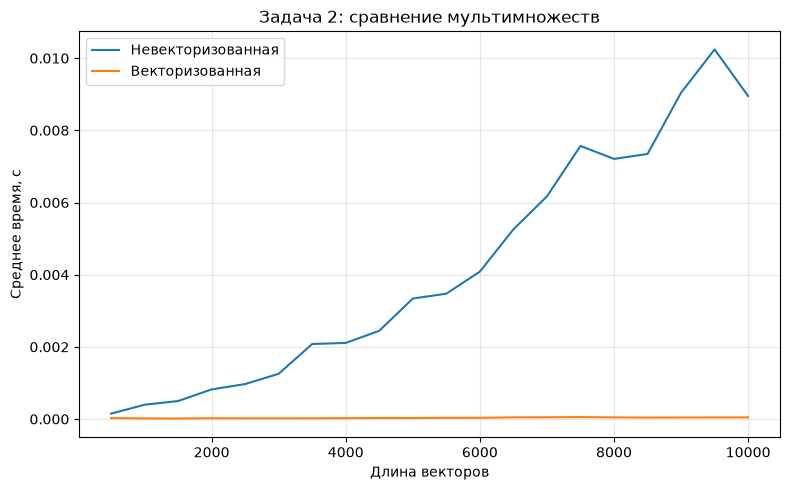

In [3]:
reload_solution_modules()

data_sizes = np.arange(500, 10_001, 500)
time_non_vectorized, time_vectorized = [], []


for size in data_sizes:
    rng = np.random.default_rng()
    data = rng.integers(0, 10, size=size)
    shuffled = data.copy()
    rng.shuffle(shuffled)
    data_list = data.tolist()
    shuffled_list = shuffled.tolist()

    start = time.perf_counter()
    for _ in range(20):
        functions.are_multisets_equal(data_list, shuffled_list)
    time_non_vectorized.append((time.perf_counter() - start) / 20)

    start = time.perf_counter()
    for _ in range(20):
        functions_vectorized.are_multisets_equal(data, shuffled)
    time_vectorized.append((time.perf_counter() - start) / 20)

figure, axis = plt.subplots(figsize=(8, 5))

axis.plot(data_sizes, time_non_vectorized, label="Невекторизованная")
axis.plot(data_sizes, time_vectorized, label="Векторизованная")

axis.set_title("Задача 2: сравнение мультимножеств")
axis.set_xlabel("Длина векторов")
axis.set_ylabel("Среднее время, с")

axis.grid(True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()


* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

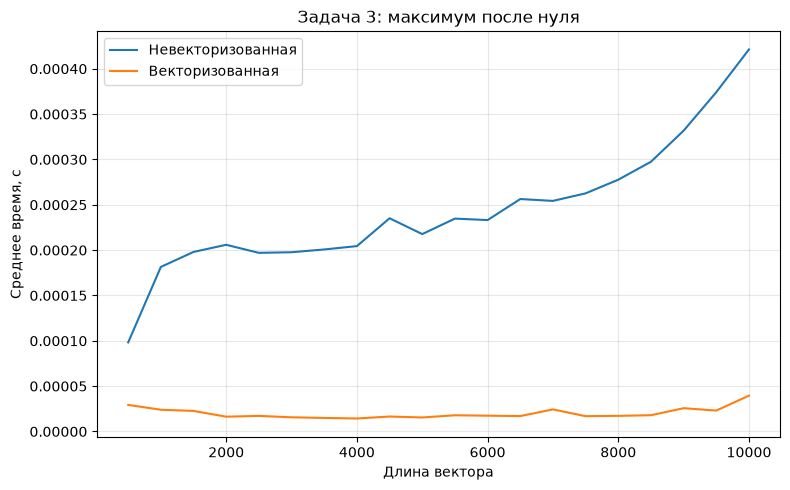

In [4]:
reload_solution_modules()

data_sizes = np.arange(500, 10_001, 500)
time_non_vectorized, time_vectorized = [], []


for size in data_sizes:
    data = np.random.default_rng().integers(0, 10, size=size)
    data[0] = 0
    data_list = data.tolist()

    start = time.perf_counter()
    for _ in range(20):
        functions.max_after_zero(data_list)
    time_non_vectorized.append((time.perf_counter() - start) / 20)

    start = time.perf_counter()
    for _ in range(20):
        functions_vectorized.max_after_zero(data)
    time_vectorized.append((time.perf_counter() - start) / 20)

figure, axis = plt.subplots(figsize=(8, 5))

axis.plot(data_sizes, time_non_vectorized, label="Невекторизованная")
axis.plot(data_sizes, time_vectorized, label="Векторизованная")

axis.set_title("Задача 3: максимум после нуля")
axis.set_xlabel("Длина вектора")
axis.set_ylabel("Среднее время, с")

axis.grid(True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()


 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


Результаты совпадают: True


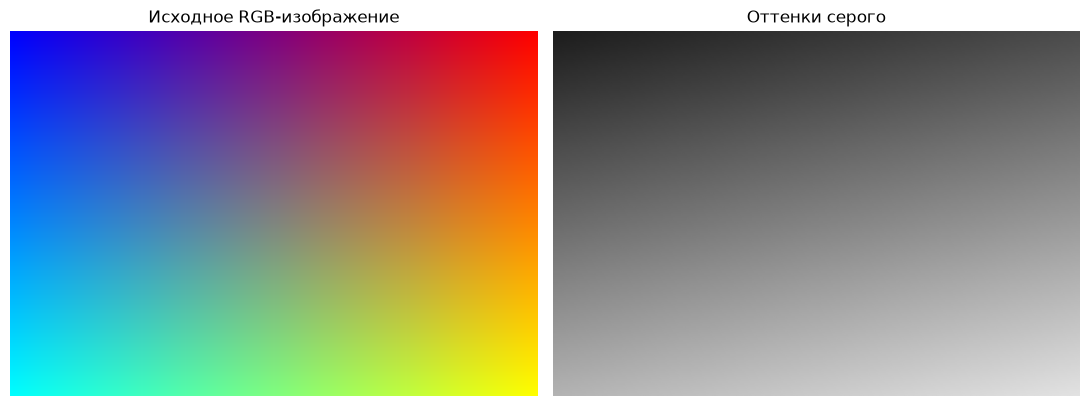

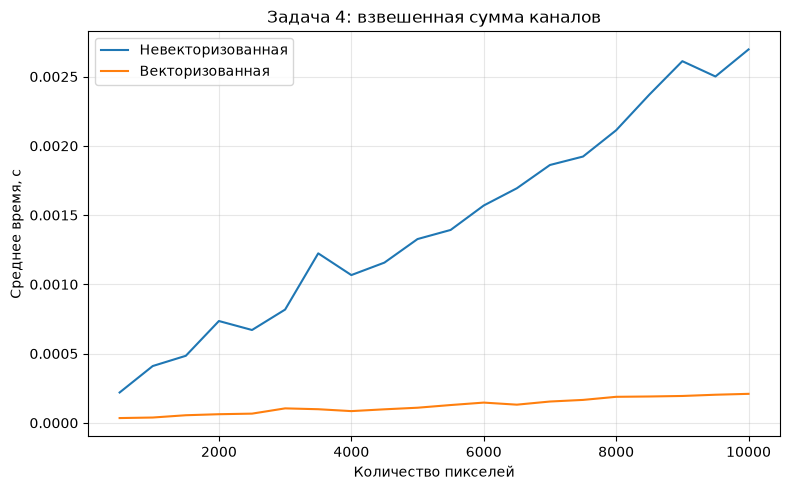

In [5]:
reload_solution_modules()

height, width = 180, 260
yy, xx = np.mgrid[0:height, 0:width]
image = np.stack((
    255 * xx / (width - 1),
    255 * yy / (height - 1),
    255 * (1 - xx / (width - 1)),
), axis=2).astype(np.uint8)
coefs = np.array([0.299, 0.587, 0.114])
gray_python = np.array(functions.convert_image(image.tolist(), coefs.tolist()))
gray_numpy = functions_vectorized.convert_image(image, coefs)
print("Результаты совпадают:", np.allclose(gray_python, gray_numpy))

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(image)
axes[0].set_title("Исходное RGB-изображение")
axes[1].imshow(gray_numpy, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Оттенки серого")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

data_sizes = np.arange(500, 10_001, 500)
time_non_vectorized, time_vectorized = [], []


for size in data_sizes:
    image_height = 100
    image_width = size // image_height
    data = np.random.default_rng().integers(
        0, 256, size=(image_height, image_width, 3)
    )
    data_list = data.tolist()

    start = time.perf_counter()
    for _ in range(20):
        functions.convert_image(data_list, coefs.tolist())
    time_non_vectorized.append((time.perf_counter() - start) / 20)

    start = time.perf_counter()
    for _ in range(20):
        functions_vectorized.convert_image(data, coefs)
    time_vectorized.append((time.perf_counter() - start) / 20)

figure, axis = plt.subplots(figsize=(8, 5))

axis.plot(data_sizes, time_non_vectorized, label="Невекторизованная")
axis.plot(data_sizes, time_vectorized, label="Векторизованная")

axis.set_title("Задача 4: взвешенная сумма каналов")
axis.set_xlabel("Количество пикселей")
axis.set_ylabel("Среднее время, с")

axis.grid(True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()


* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

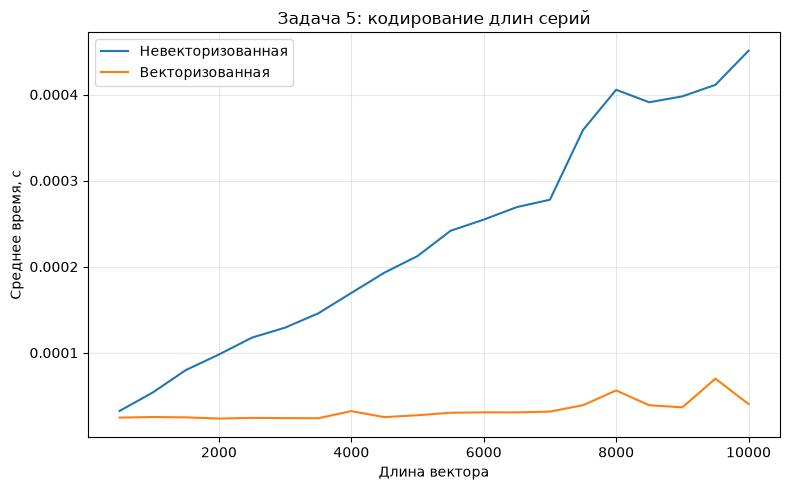

In [6]:
reload_solution_modules()

data_sizes = np.arange(500, 10_001, 500)
time_non_vectorized, time_vectorized = [], []


for size in data_sizes:
    data = np.random.default_rng().integers(0, 10, size=size)
    data_list = data.tolist()

    start = time.perf_counter()
    for _ in range(20):
        functions.run_length_encoding(data_list)
    time_non_vectorized.append((time.perf_counter() - start) / 20)

    start = time.perf_counter()
    for _ in range(20):
        functions_vectorized.run_length_encoding(data)
    time_vectorized.append((time.perf_counter() - start) / 20)

figure, axis = plt.subplots(figsize=(8, 5))

axis.plot(data_sizes, time_non_vectorized, label="Невекторизованная")
axis.plot(data_sizes, time_vectorized, label="Векторизованная")

axis.set_title("Задача 5: кодирование длин серий")
axis.set_xlabel("Длина вектора")
axis.set_ylabel("Среднее время, с")

axis.grid(True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()


 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

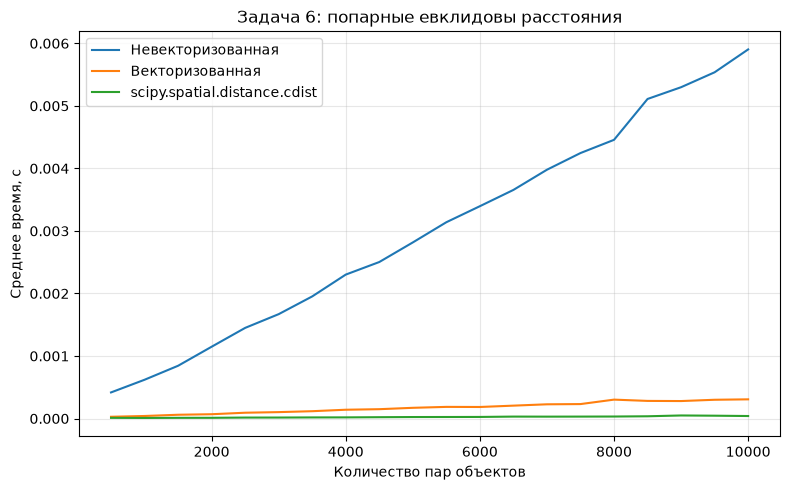

In [7]:
reload_solution_modules()

from scipy.spatial.distance import cdist

data_sizes = np.arange(500, 10_001, 500)
time_non_vectorized, time_vectorized, time_scipy = [], [], []


for size in data_sizes:
    rng = np.random.default_rng()
    x_count = 100
    y_count = size // x_count
    x_data = rng.integers(0, 10, size=(x_count, 10))
    y_data = rng.integers(0, 10, size=(y_count, 10))
    x_list = x_data.tolist()
    y_list = y_data.tolist()

    start = time.perf_counter()
    for _ in range(20):
        functions.pairwise_distance(x_list, y_list)
    time_non_vectorized.append((time.perf_counter() - start) / 20)

    start = time.perf_counter()
    for _ in range(20):
        functions_vectorized.pairwise_distance(x_data, y_data)
    time_vectorized.append((time.perf_counter() - start) / 20)

    start = time.perf_counter()
    for _ in range(20):
        cdist(x_data, y_data)
    time_scipy.append((time.perf_counter() - start) / 20)

figure, axis = plt.subplots(figsize=(8, 5))

axis.plot(data_sizes, time_non_vectorized, label="Невекторизованная")
axis.plot(data_sizes, time_vectorized, label="Векторизованная")
axis.plot(data_sizes, time_scipy, label="scipy.spatial.distance.cdist")

axis.set_title("Задача 6: попарные евклидовы расстояния")
axis.set_xlabel("Количество пар объектов")
axis.set_ylabel("Среднее время, с")

axis.grid(True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()


### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

## Краткий отчёт

В этой работе были реализованы **шесть функций** двумя способами: обычным Python и средствами `NumPy`.

> Главный результат: векторизованные операции обычно работают быстрее, особенно на больших массивах.

1. Результаты двух реализаций сопоставлены.
2. Время измерено несколько раз, а на график вынесен лучший результат.

*Кодирование длин серий* удобно применять к последовательностям с большим числом повторов, а матрица расстояний используется во многих алгоритмах машинного обучения.

[Документация NumPy](https://numpy.org/doc/stable/) помогла разобраться с операциями над массивами.


> Результаты выполнения задач и аналитики данных с использованием векторизации.

## Основные показатели
1. Использование библиотеки **`numpy`** для оптимизации вычислений
2. Репозиторий проекта: [GitHub K35177/ML_Kamalov](https://github.com/K35177/ML_Kamalov)

## Сводная таблица
| Инструмент | Назначение | Статус |
| :--- | :--- | :--- |
| **NumPy** | Матричные операции | `Активно` |
| **Git** | Управление версиями | `Синхронизировано` |

---

## Блок кода
```python
import numpy as np

# Пример векторизированного вычисления
def compute_matrix(data):
    matrix = np.array(data)
    return np.dot(matrix, matrix.T)